# Test at First 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

<Axes: xlabel='skills_count', ylabel='skill_pay'>

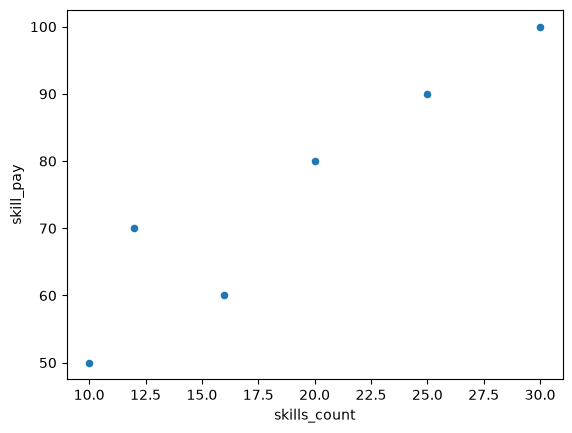

In [ ]:
data = {
    'job_skills' : ['python','sql','java','javascript','c++','C#'],
    'skills_count': [30,25,20,12,16,10],
    'skill_pay' :   [100,90,80,70,60,50]
}

df = pd.DataFrame(data)

df.plot(kind='scatter', x='skills_count' , y='skill_pay')

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [8]:
df = df[df['job_title_short'] == 'Data Analyst']

In [54]:
df_explode = df.explode('job_skills')

skill_state = df_explode.groupby('job_skills').agg(
    skill_count = ('job_skills' , 'count'),
    median_salary = ('salary_year_avg','median')
)
top_skills= 10
skills_stare = skill_state.sort_values(by='skill_count' , ascending=False).head(top_skills)

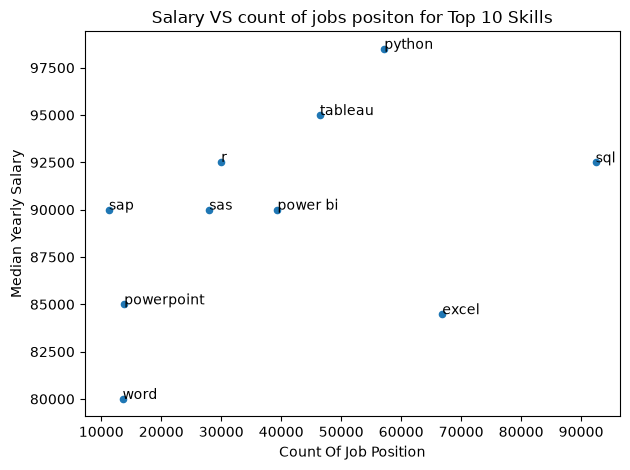

In [21]:
skills_stare.plot(kind='scatter' , x='skill_count' , y='median_salary')
plt.ylabel('Median Yearly Salary')
plt.xlabel('Count Of Job Position')
plt.title('Salary VS count of jobs positon for Top 10 Skills')
for i , txt in enumerate(skills_stare.index):
    plt.text(skills_stare['skill_count'].iloc[i] , skills_stare['median_salary'].iloc[i] , txt)
plt.tight_layout()
plt.show()

In [24]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')

df_DA_pivote = df_DA_explode.pivot_table(index='job_posted_month_no' , columns='job_skills' , aggfunc='size' , fill_value=0)

df_DA_pivote.loc['Total'] = df_DA_pivote.sum() # Just for Try 

df_DA_pivote = df_DA_pivote[df_DA_pivote.loc['Total'].sort_values(ascending=False).index]
df_DA_pivote = df_DA_pivote.drop('Total') # Just for Try 

df_DA_pivote

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

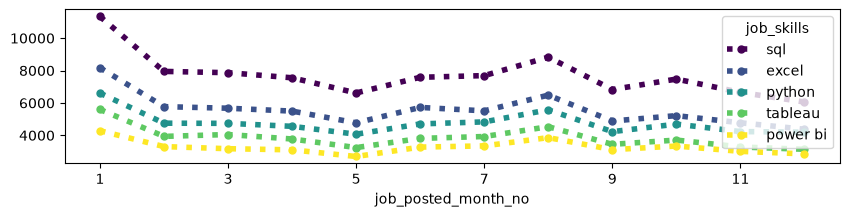

In [31]:
df_DA_pivote.iloc[:,:5].plot(
    kind='line',
    linewidth=4,
    linestyle = ':',
    colormap='viridis',
    marker='o',
    markersize = 5,
    figsize=(10,2)
)

In [38]:
skills_stare

,skill_count,median_salary
job_skills,,
sql,384849,120000.0
python,380909,125000.0
aws,145381,135000.0
azure,132527,125000.0
r,130892,119550.0
tableau,127213,111175.0
excel,127018,92500.0
spark,114609,140000.0
power bi,98147,102000.0


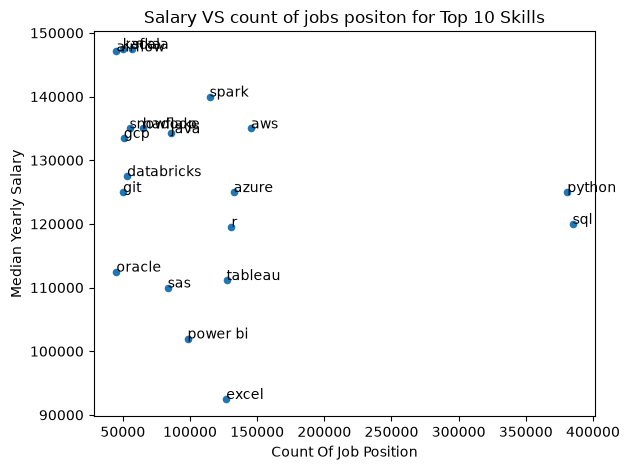

In [40]:
skills_stare.plot(kind='scatter' , x='skill_count' , y='median_salary')
plt.ylabel('Median Yearly Salary')
plt.xlabel('Count Of Job Position')
plt.title('Salary VS count of jobs positon for Top 10 Skills')
for i , txt in enumerate(skills_stare.index):
    plt.text(skills_stare['skill_count'].iloc[i] , skills_stare['median_salary'].iloc[i] , txt)
plt.tight_layout()
plt.show()

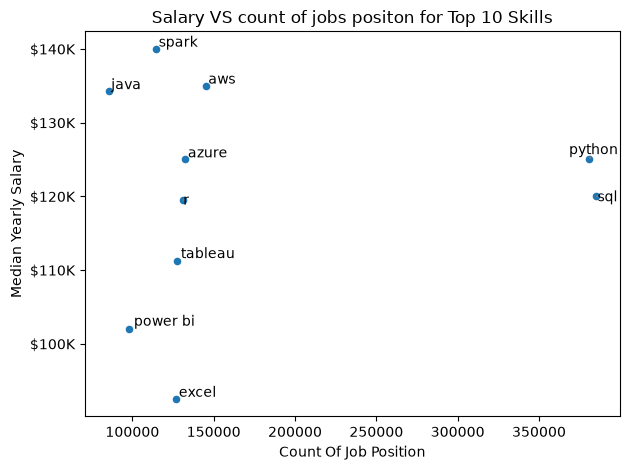

In [55]:
from adjustText import adjust_text # all these for practice with YouTube video 
# fig , ax = plt.subplots()


skills_stare.plot(kind='scatter' , x='skill_count' , y='median_salary')

texts = []

plt.title(f'Salary VS count of jobs positon for Top {top_skills} Skills')
for i , txt in enumerate(skills_stare.index):
    texts.append(plt.text(skills_stare['skill_count'].iloc[i] , skills_stare['median_salary'].iloc[i] , txt))

adjust_text(texts , arrowprops=dict(arrowstyle='->' , color='gray' , lw=1))

plt.ylabel('Median Yearly Salary')
plt.xlabel('Count Of Job Position')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
plt.tight_layout()
plt.show()

